In [1]:
from typing import Literal, TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class RouterState(TypedDict):
    text: str
    text_length: int
    processed_output: str

In [3]:
def calculate_length_node(state: RouterState):
    length = len(state["text"])
    return {"text_length": length}

In [4]:
def short_text_handler(state: RouterState):
    return {"processed_output": f"SHORT ({state['text_length']} chars): {state['text'].upper()}"}

In [24]:
def long_text_handler(state: RouterState):
    return {"processed_output": f"LONG ({state['text_length']} chars): Truncated to 100 chars '{state['text'][:100]}...'"}

In [25]:
def route_by_length(state: RouterState) -> Literal["short_text_handler", "long_text_handler"]:
    # Route based on the updated text_length state
    if state["text_length"] <= 100:
        return "short_text_handler"
    else:
        return "long_text_handler"

In [26]:
graph = StateGraph(RouterState)
graph.add_node("calculate_length_node", calculate_length_node)
graph.add_node("short_text_handler", short_text_handler)
graph.add_node("long_text_handler", long_text_handler)
graph.add_edge(START, "calculate_length_node")
graph.add_conditional_edges("calculate_length_node",route_by_length)
graph.add_edge("short_text_handler", END)
graph.add_edge("long_text_handler", END)


In [27]:
workflow = graph.compile()

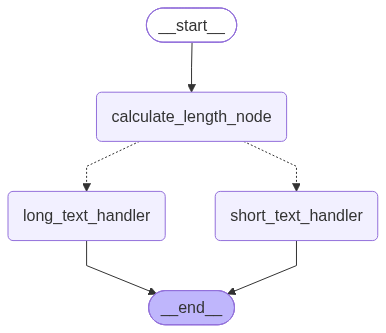

In [22]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [28]:
initial_state = {
    "text": "Bangladesh is a beautiful country in South Asia. It is a land of rivers, green fields, villages, and natural beauty. The country became independent on 16 December 1971 after a nine-month Liberation War. Since then, Bangladesh has been developing as an independent nation. The people of Bangladesh are known for their hospitality, courage, and love for their motherland."
}

final_state = workflow.invoke(initial_state)

final_state

{'text': 'Bangladesh is a beautiful country in South Asia. It is a land of rivers, green fields, villages, and natural beauty. The country became independent on 16 December 1971 after a nine-month Liberation War. Since then, Bangladesh has been developing as an independent nation. The people of Bangladesh are known for their hospitality, courage, and love for their motherland.',
 'text_length': 369,
 'processed_output': "LONG (369 chars): Truncated to 100 chars 'Bangladesh is a beautiful country in South Asia. It is a land of rivers, green fields, villages, and...'"}